<a href="https://colab.research.google.com/github/hyoungjun0118/-/blob/main/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

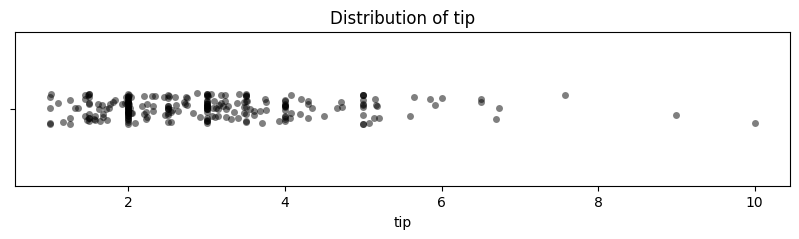

Tip 데이터의 평균: 3.00
Tip 데이터의 분산: 1.91


In [34]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 로드
tips = sns.load_dataset('tips')

# 2. 분포 시각화 (이미지의 Strip Plot 구현)
plt.figure(figsize=(10, 2))
sns.stripplot(x=tips['tip'], color='black', alpha=0.5)
plt.title('Distribution of tip')
plt.show()

# 3. 평균과 분산 계산
tip_mean = tips['tip'].mean()
tip_var = tips['tip'].var()

print(f"Tip 데이터의 평균: {tip_mean:.2f}")
print(f"Tip 데이터의 분산: {tip_var:.2f}")

In [35]:
# 가상의 이상치 추가 ($50 팁)
outlier_tips = pd.concat([tips['tip'], pd.Series([50.0])])

print(f"원본 평균: {tips['tip'].mean():.2f}")
print(f"이상치 추가 후 평균: {outlier_tips.mean():.2f}")
print(f"원본 중앙값: {tips['tip'].median():.2f}")
print(f"이상치 추가 후 중앙값: {outlier_tips.median():.2f}")
# -> 중앙값은 거의 변하지 않지만, 평균은 크게 튀는 '함정'을 확인할 수 있습니다.

원본 평균: 3.00
이상치 추가 후 평균: 3.19
원본 중앙값: 2.90
이상치 추가 후 중앙값: 2.92


In [39]:
from sklearn.model_selection import train_test_split

# 설정: 30개의 표본을 뽑는다고 가정
sample_size = 30

# [1] 단순 무작위 추출 (Simple Random Sampling)
simple_sample = tips.sample(n=sample_size, random_state=42)

# [2] 계통 추출 (Systematic Sampling)
step = len(tips) // sample_size
systematic_sample = tips.iloc[::step][:sample_size]

# [3] 층화 추출 (Stratified Sampling) - 'day'(요일)별 비율 유지
# 각 층의 최소 샘플수를 보장하기 위해 요일별로 균등하게 배분
stratified_sample, _ = train_test_split(tips, train_size=sample_size, stratify=tips['day'], random_state=42)

# 결과 비교 테이블 생성
results = pd.DataFrame({
    'Metric': ['Mean (평균)', 'Variance (분산)'],
    'Population (모집단)': [tips['tip'].mean(), tips['tip'].var()],
    'Simple Random': [simple_sample['tip'].mean(), simple_sample['tip'].var()],
    'Systematic': [systematic_sample['tip'].mean(), systematic_sample['tip'].var()],
    'Stratified': [stratified_sample['tip'].mean(), stratified_sample['tip'].var()]
})